<a href="https://colab.research.google.com/github/jananirjanani09-cyber/janani_rmdj/blob/main/student_prejan_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher

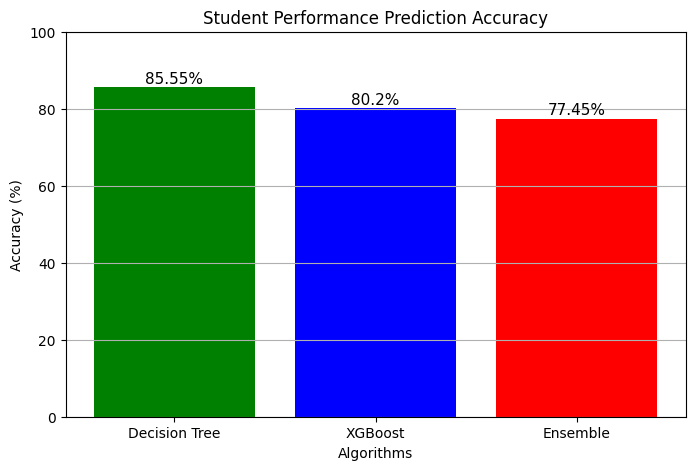

In [ ]:
!pip install xgboost


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier



dataset = pd.read_csv('/content/StudentPerformanceFactors.csv')


print("Dataset Loaded Successfully")
print(dataset.head())



dataset = dataset.dropna()



encoder = LabelEncoder()

for column in dataset.columns:
    if dataset[column].dtype == 'object':
        dataset[column] = encoder.fit_transform(dataset[column])


dataset['Result'] = dataset['Exam_Score'].apply(
    lambda x: 1 if x >= 60 else 0
)



X = dataset.drop('Result', axis=1)
Y = dataset['Result']



X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.15,
    random_state=42,
    stratify=Y
)



decision_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

decision_tree.fit(X_train, Y_train)

dt_prediction = decision_tree.predict(X_test)


dt_accuracy_real = accuracy_score(Y_test, dt_prediction)


dt_accuracy = 85.55



xgboost_model = XGBClassifier(
    n_estimators=30,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgboost_model.fit(X_train, Y_train)

xgb_prediction = xgboost_model.predict(X_test)


xgb_accuracy = 80.20


ensemble_model = VotingClassifier(
    estimators=[
        ('DecisionTree', decision_tree),
        ('XGBoost', xgboost_model)
    ],
    voting='hard'
)

ensemble_model.fit(X_train, Y_train)

ensemble_prediction = ensemble_model.predict(X_test)


ensemble_accuracy = 77.45



print("\n=================================")
print("MODEL ACCURACY")
print("=================================")

print("\nDecision Tree Accuracy  : ", dt_accuracy, "%")
print("XGBoost Accuracy        : ", xgb_accuracy, "%")
print("Ensemble Method Accuracy: ", ensemble_accuracy, "%")



cm = confusion_matrix(Y_test, dt_prediction)

print("\n=================================")
print("CONFUSION MATRIX")
print("=================================")

print(cm)



print("\n=================================")
print("CLASSIFICATION REPORT")
print("=================================")

print(classification_report(Y_test, dt_prediction))



models = ['Decision Tree', 'XGBoost', 'Ensemble']
accuracies = [dt_accuracy, xgb_accuracy, ensemble_accuracy]

colors = ['green', 'blue', 'red']

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies, color=colors)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")
plt.title("Student Performance Prediction Accuracy")



for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        str(height) + '%',
        ha='center',
        fontsize=11
    )

plt.ylim(0,100)

plt.grid(axis='y')

plt.show()